In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.stattools import adfuller

In [2]:
df=pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\IntelliPaat\EDA CSV files\Walmart DataSet(Capstone4).csv")
df.sample(6)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
3816,27,23-12-2011,2739019.75,0,41.59,3.587,140.528765,7.906
2252,16,24-02-2012,495720.30,0,26.21,3.129,196.949901,6.162
1190,9,24-12-2010,873347.55,0,50.93,2.886,214.930153,6.560
4579,33,26-02-2010,284052.77,0,56.50,2.825,126.552286,10.115
4742,34,16-07-2010,930269.79,0,78.53,2.621,126.149806,9.816
158,2,21-05-2010,1896937.10,0,74.83,2.826,210.276844,8.200


In [3]:
# What is the size of the given table?
df.shape
# There are 6435 rows and 8 columns in the table

(6435, 8)

In [4]:
# How do the columns look like?
df.info()
# Only Date column is a Object Data Type

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [5]:
# Are there any NULL Values in the data that need to be removed?
df.isnull().sum()
# no Null Values

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [6]:
# Are there any duplicate values in the data that need removal?
df.duplicated().sum()
# No duplicate rows in the data set

0

In [7]:
# How many unique values are there in each columns
df.nunique()

Store             45
Date             143
Weekly_Sales    6435
Holiday_Flag       2
Temperature     3528
Fuel_Price       892
CPI             2145
Unemployment     349
dtype: int64

<Axes: >

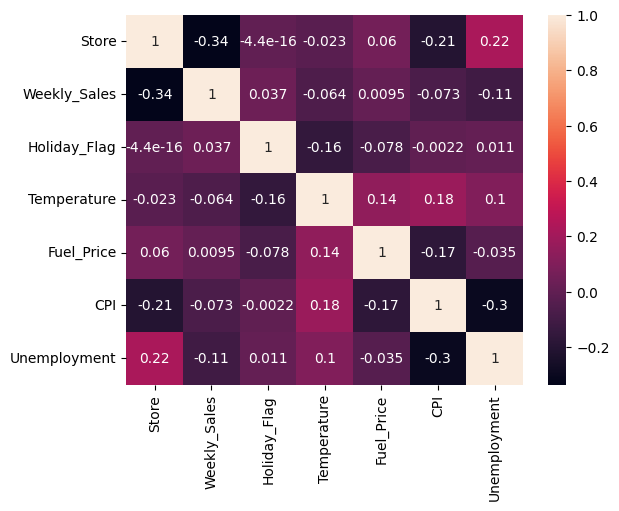

In [8]:
# is there a strong correlation between Weekly_Sales and any other column?

sns.heatmap(df.corr(numeric_only=True), annot=True)

# No significant positive or negative correlation found with Weekly Sales found

In [9]:
# which store had maximum sales- find out by week date and total sales

max_sales_store = df.sort_values('Weekly_Sales', ascending=False)[:1]
max_sales_store

# Store number 14 was found to have max sales= USD 3818686.45 in the week ending 24 Dec 2010

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
1905,14,24-12-2010,3818686.45,0,30.59,3.141,182.54459,8.724


In [10]:
# which are the top 5 stores by weekly sales and week date and sales numbers?

best_sales_store = df.sort_values('Weekly_Sales', ascending=False)[:5]
best_sales_store

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
1905,14,24-12-2010,3818686.45,0,30.59,3.141,182.544590,8.724
2763,20,24-12-2010,3766687.43,0,25.17,3.141,204.637673,7.484
1333,10,24-12-2010,3749057.69,0,57.06,3.236,126.983581,9.003
527,4,23-12-2011,3676388.98,0,35.92,3.103,129.984548,5.143
1762,13,24-12-2010,3595903.20,0,34.90,2.846,126.983581,7.795


In [11]:
# which is the store with minimum sales by week date and sales numbers?

min_sales_store = df.sort_values('Weekly_Sales', ascending=True)[:1]
min_sales_store

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
4619,33,03-12-2010,209986.25,0,52.82,3.041,126.731333,9.265


In [12]:
# which are the bottom 5 stores by weekly sales and week date and sales numbers?

least_sales_stores = df.sort_values('Weekly_Sales', ascending=True)[0:5]
least_sales_stores

# Interestingly, all the 5 bottom 5 slots by sales were taken by stor number 33.

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
4619,33,03-12-2010,209986.25,0,52.82,3.041,126.731333,9.265
4614,33,29-10-2010,213538.32,0,71.34,3.130,126.436419,9.265
4675,33,30-12-2011,215359.21,1,51.60,3.428,130.071032,8.010
4623,33,31-12-2010,219804.85,1,52.91,3.148,127.087677,9.265
4671,33,02-12-2011,220060.35,0,59.12,3.701,129.845967,8.010


In [13]:
# What is the difference between maxium sales and minimum sales
int(max_sales_store['Weekly_Sales'])- int(min_sales_store['Weekly_Sales'])

3608700

In [14]:
# which are the weeks for max sales across all the stores combined by Total Sales?

print(df.groupby(['Date'])['Weekly_Sales'].sum().sort_values(ascending=False)[:5])

Date
24-12-2010    80931415.60
23-12-2011    76998241.31
25-11-2011    66593605.26
26-11-2010    65821003.24
17-12-2010    61820799.85
Name: Weekly_Sales, dtype: float64


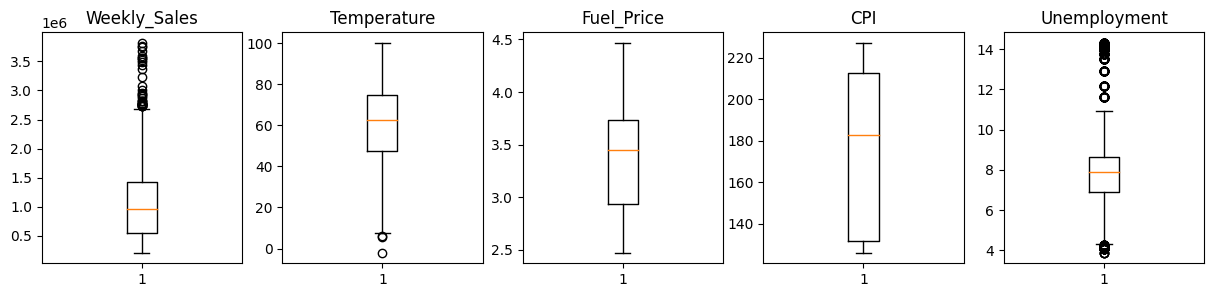

In [15]:
# Find out which all columns have outliers in the data

columns=['Weekly_Sales','Temperature','Fuel_Price','CPI','Unemployment']
plt.figure(figsize=(15,3))
for i,col in enumerate(columns):
    plt.subplot(1,5,i+1)
    plt.boxplot(df[col])
    plt.title(col)
plt.show()

# We found Outliers in Weekly Sales, Temperature and Unemployment columns

In [16]:
# remove outliers in the data using the IQR method

outlier_list=['Weekly_Sales', 'Unemployment', 'Temperature']
for i in outlier_list:
    Q1=df[i].quantile(0.25)
    Q3=df[i].quantile(0.75)
    IQR=Q3-Q1
    UF=Q3+1.5*IQR
    LF=Q1-1.5*IQR
    df=df[(df[i]>LF) & (df[i]<UF)]

In [17]:
# Split the Date column into Month and Year and finally drop the Date column

df['Date'] = pd.to_datetime(df['Date']) 
df['Month']=df['Date'].dt.month
df['Year']=df['Date'].dt.year
df['Day']=df['Date'].dt.day
df['Week']=df['Date'].dt.isocalendar().week

In [18]:
df.drop(columns=['Date'], inplace=True)
df.sample(4)

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Year,Day,Week
5268,37,540625.79,0,78.94,3.561,220.428712,6.989,5,2012,25,21
5563,39,1487797.54,0,82.89,3.407,220.623405,6.623,7,2012,27,30
1321,10,1645892.97,0,86.01,3.001,126.234600,9.003,1,2010,10,1
2077,15,624114.56,0,73.34,3.915,135.783742,7.806,7,2011,15,28


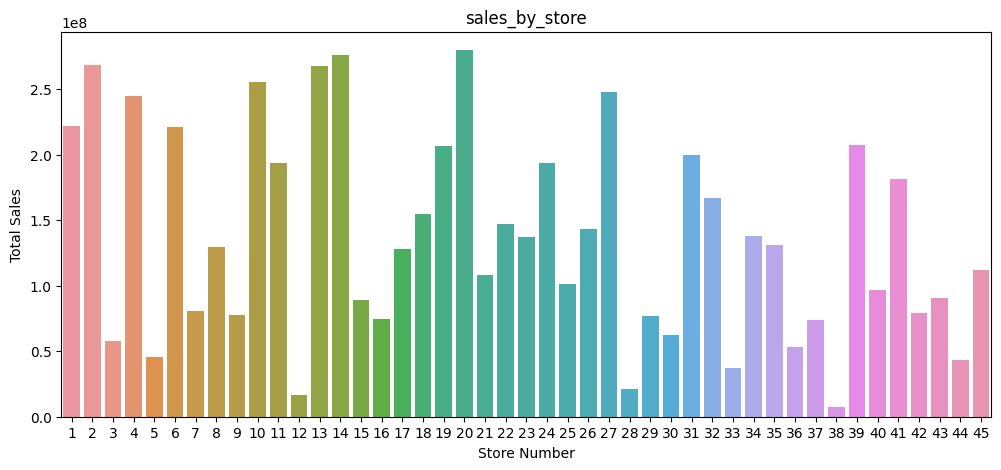

In [19]:
sales_by_store = df.groupby('Store')['Weekly_Sales'].sum().reset_index()
plt.figure(figsize=(12,5))
sns.barplot(x=sales_by_store['Store'], y=sales_by_store['Weekly_Sales'])
plt.xlabel("Store Number")
plt.ylabel("Total Sales")
plt.title("sales_by_store")
plt.show()

In [20]:
sales_by_store_and_year= df.groupby(['Store','Year'])['Weekly_Sales'].sum().reset_index()

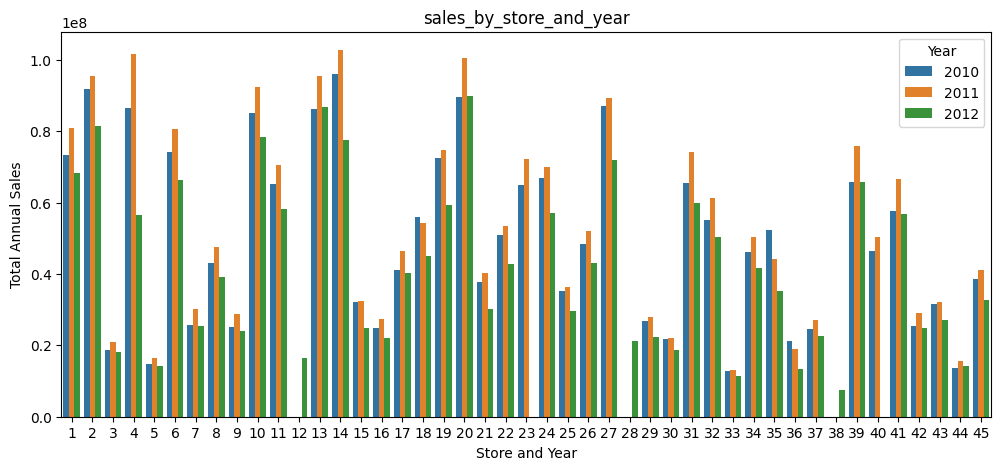

In [21]:
plt.figure(figsize=(12,5))
sns.barplot(x=sales_by_store_and_year['Store'], y=sales_by_store_and_year['Weekly_Sales'], hue=sales_by_store_and_year['Year'])
plt.xlabel("Store and Year")
plt.ylabel("Total Annual Sales")
plt.title("sales_by_store_and_year")
plt.show()

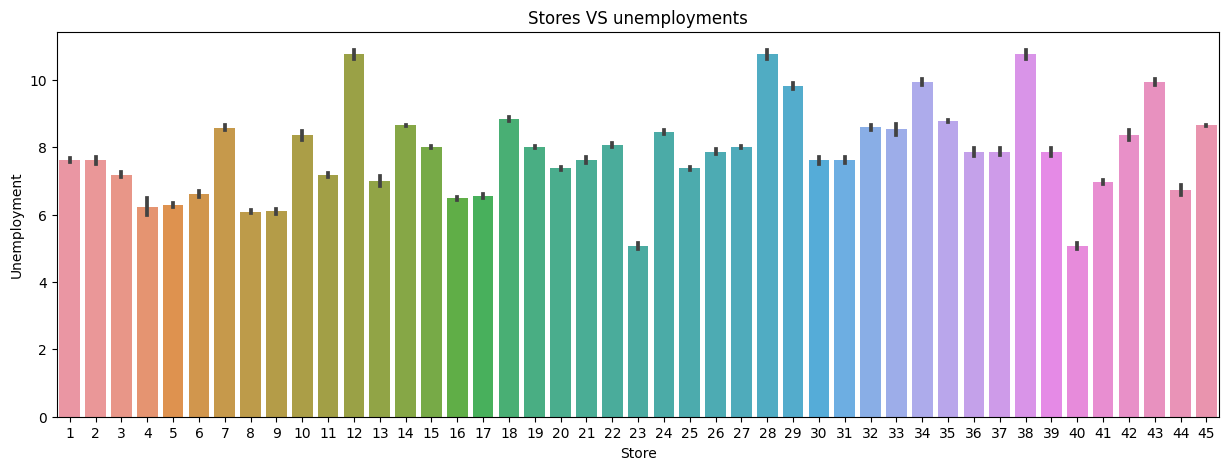

In [22]:
# Is unemployment impacting the sales?
plt.figure(figsize=(15,5))
sns.barplot(x=df['Store'], y=df['Unemployment'])
plt.title('Stores VS unemployments')
plt.show()

In [23]:
correlations_df=df.groupby('Store')['Weekly_Sales','Unemployment'].corr().unstack()
correlations_df.sample(4)

Weekly_Sales              Unemployment             
      Weekly_Sales Unemployment Weekly_Sales Unemployment
Store                                                    
15             1.0     0.078905     0.078905          1.0
16             1.0    -0.070864    -0.070864          1.0
13             1.0    -0.400254    -0.400254          1.0
27             1.0    -0.002535    -0.002535          1.0

In [24]:
# stores that had negative correlation with unemployment was Store 44
# Store 44- with increase in Unemployment, Store 44 had max reduction in Sales

correlations_df['Weekly_Sales']['Unemployment'].sort_values(ascending=True)[:1]

Store
44   -0.780076
Name: Unemployment, dtype: float64

In [25]:
# stores that had positive correlation with unemployment was Store 36
# Store 36- with increase in Unemployment, Store 36 had max increase in sales

correlations_df['Weekly_Sales']['Unemployment'].sort_values(ascending=False)[:1]

Store
36    0.833734
Name: Unemployment, dtype: float64

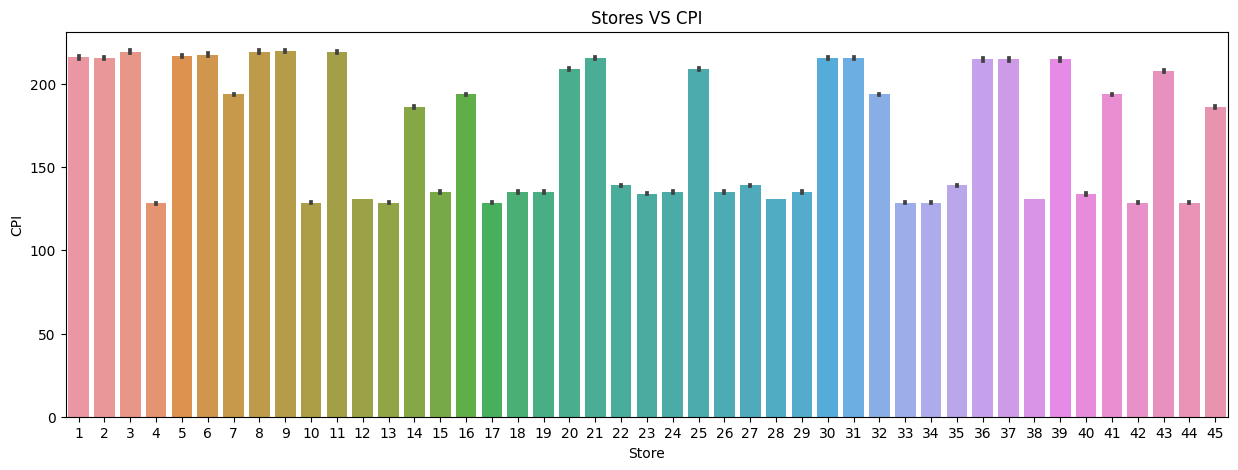

In [26]:
# Is increasing CPI impacting the sales?
plt.figure(figsize=(15,5))
sns.barplot(x=df['Store'], y=df['CPI'])
plt.title('Stores VS CPI')
plt.show()

In [27]:
CPI_correlations=df.groupby('Store')['Weekly_Sales','CPI'].corr().unstack()
CPI_correlations.sample(4)

Weekly_Sales                    CPI     
      Weekly_Sales       CPI Weekly_Sales  CPI
Store                                         
38             1.0 -0.109557    -0.109557  1.0
41             1.0  0.392293     0.392293  1.0
18             1.0 -0.193541    -0.193541  1.0
27             1.0 -0.235769    -0.235769  1.0

In [28]:
CPI_correlations['Weekly_Sales']['CPI'].sort_values(ascending=True)[:1]

# Store 38 had max negative correlation
# with increase in CPI, sales of store 38 reduced maximum

Store
36   -0.915095
Name: CPI, dtype: float64

In [29]:
CPI_correlations['Weekly_Sales']['CPI'].sort_values(ascending=False)[:1]

# Store 44 had max positive correlation
# with increase in CPI, sales of store 44 also increased maximum

Store
44    0.74015
Name: CPI, dtype: float64

##**Time Series Prediction**##

In [30]:
df=pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\IntelliPaat\EDA CSV files\Walmart DataSet(Capstone4).csv")
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [31]:
df['Date']=pd.to_datetime(df['Date'], format="%d-%m-%Y")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB


In [32]:
df['Year']=df['Date'].dt.year
df['Month']=df['Date'].dt.month
df['Day']=df['Date'].dt.day
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Day
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,12
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,19
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,26
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,5


In [33]:
df.set_index('Date', inplace=True)
df.index.name=None
df.sample(3)

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Day
2012-01-06,42,636372.37,0,59.85,3.443,130.157516,7.545,2012,1,6
2010-10-15,32,1096692.88,0,52.96,2.762,190.862309,9.137,2010,10,15
2012-08-31,7,586467.16,0,60.46,3.556,198.096734,7.872,2012,8,31


In [34]:
df=df.drop(columns=['Holiday_Flag','Temperature','Fuel_Price','CPI','Unemployment','Year','Month','Day'])
df.sample(3)

,Store,Weekly_Sales
2010-03-12,29,519042.49
2010-03-12,36,441434.20
2012-03-02,4,2206319.90


In [35]:
i=int(input("Please Enter the Store Number for which sales need to be predicted : "))
X=df[df['Store']==i]
X.drop(columns=['Store'],inplace=True)
X.sample(3)

Please Enter the Store Number for which sales need to be predicted :  1


,Weekly_Sales
2011-03-04,1636263.41
2012-09-28,1437059.26
2011-12-02,1584083.95


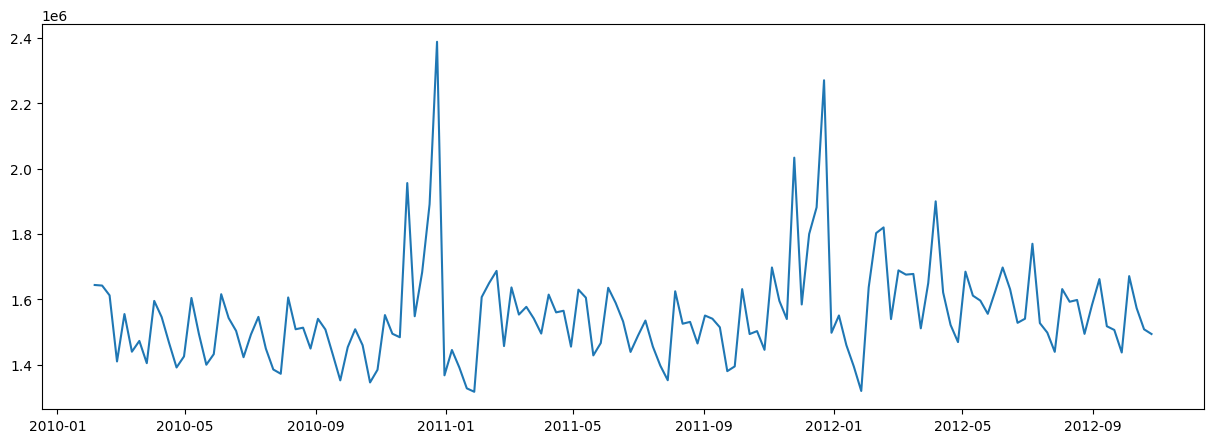

In [36]:
plt.figure(figsize=(15,5))
plt.plot(X['Weekly_Sales'])

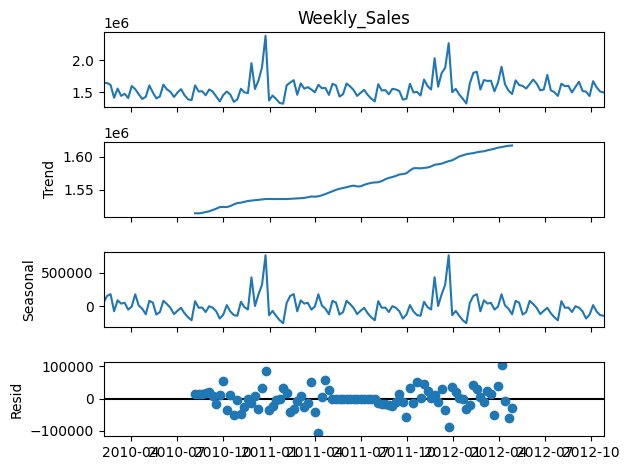

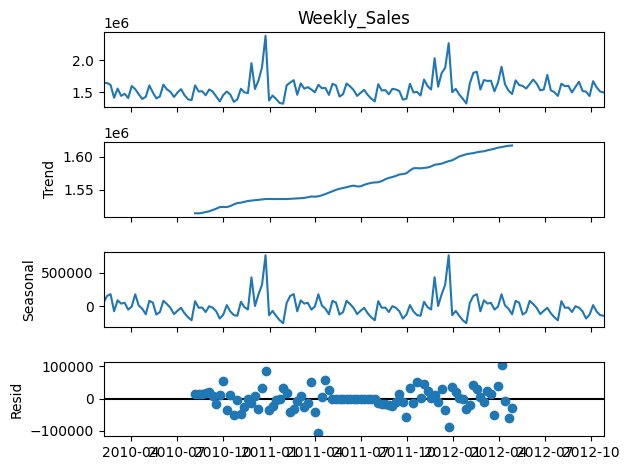

In [37]:
decompose = seasonal_decompose(X['Weekly_Sales'], period = 52)
decompose.plot()

In [38]:
mean_data = X.rolling(window = 52).mean()
mean_data[48:55]

,Weekly_Sales
2011-01-07,NaN
2011-01-14,NaN
2011-01-21,NaN
2011-01-28,1.514594e+06
2011-02-04,1.513881e+06
2011-02-11,1.514028e+06
2011-02-18,1.515468e+06


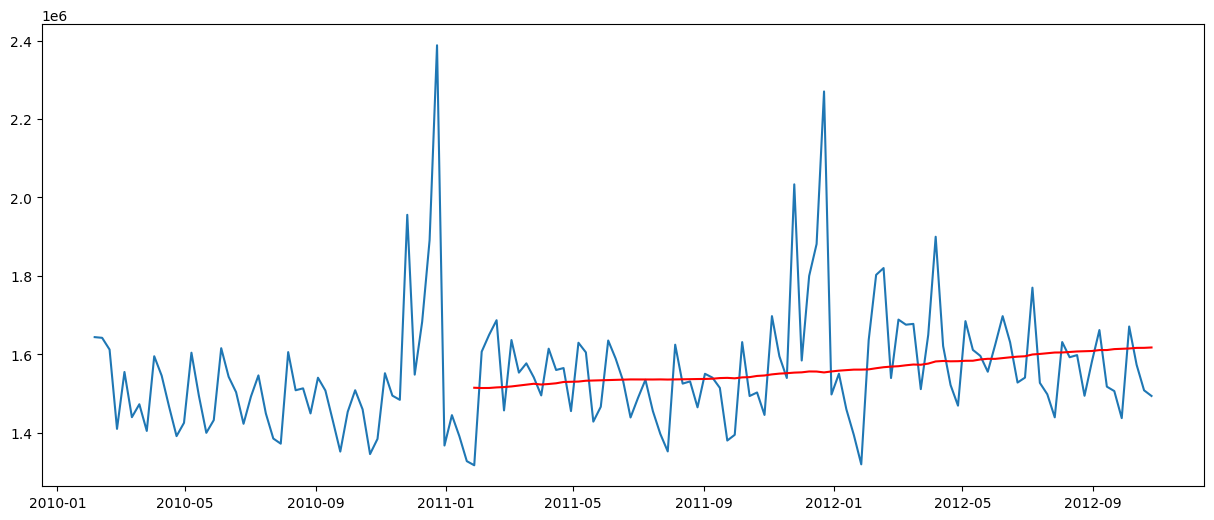

In [39]:
plt.figure(figsize=(15,6))
plt.plot(X)
plt.plot(mean_data, color = 'red')

# Visually it looks like slightly non stationery data, but we need to check with AD Fuller test
# mean line is strainght without seasonality- this confirms that the data is 52 weeks data that repeats annually

In [40]:
X

,Weekly_Sales
2010-02-05,1643690.90
2010-02-12,1641957.44
2010-02-19,1611968.17
2010-02-26,1409727.59
2010-03-05,1554806.68
...,...
2012-09-28,1437059.26
2012-10-05,1670785.97
2012-10-12,1573072.81
2012-10-19,1508068.77


In [41]:
result=adfuller(X['Weekly_Sales'].dropna())
if(result[1])<0.05:
    print('Data IS stationary, p value -',result[1])
else:
    print('Data is NOT stationary, p value -',result[1])

Data IS stationary, p value - 1.3877788330759307e-05


In [42]:
plt.figure(figsize=(15,5))


<Figure size 1500x500 with 0 Axes>

<Figure size 1500x500 with 0 Axes>

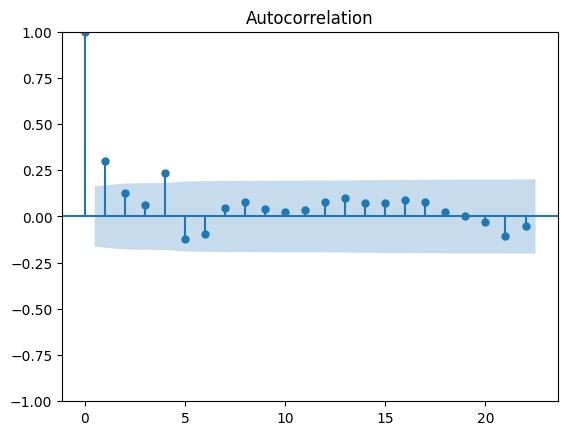

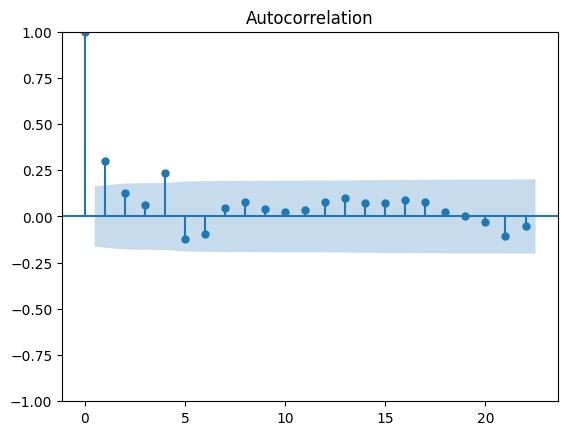

In [43]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(X['Weekly_Sales'].dropna())

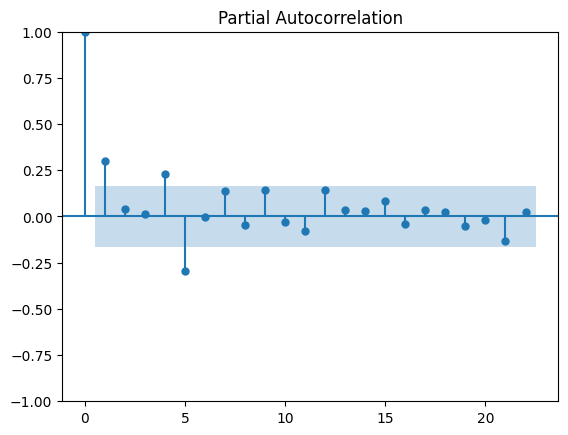

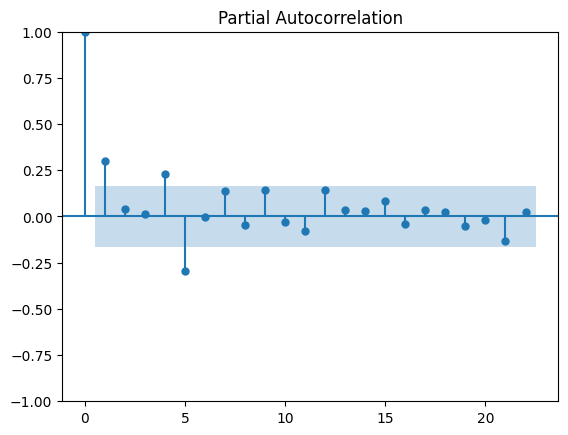

In [44]:
plot_pacf(X['Weekly_Sales'].dropna())

In [45]:
final_data=X['Weekly_Sales'].dropna()
length=len(final_data)
train_len=int(length*0.8)
print(f'complete length- {length}  train length- {train_len} ')

complete length- 143  train length- 114 


In [46]:
final_data=pd.DataFrame(final_data)
final_data

,Weekly_Sales
2010-02-05,1643690.90
2010-02-12,1641957.44
2010-02-19,1611968.17
2010-02-26,1409727.59
2010-03-05,1554806.68
...,...
2012-09-28,1437059.26
2012-10-05,1670785.97
2012-10-12,1573072.81
2012-10-19,1508068.77


In [47]:
train_data = final_data.iloc[:train_len]['Weekly_Sales']
test_data = final_data .iloc[train_len+1:]['Weekly_Sales']

In [48]:
from statsmodels.tsa.arima.model import ARIMA

# p- AR Model Lags- coming from PACF =1
# d- differencing =0
# q- MA Lags- coming from ACF = 1
# arima order= p,d,q
    
arima_model = ARIMA(train_data, order = (2, 0, 2))
trained_model = arima_model.fit()

In [49]:
final_data['ARIMA_Predicted'] = trained_model.predict(start=train_len, end=length-1, dynamic = True)

In [50]:
final_data

,Weekly_Sales,ARIMA_Predicted
2010-02-05,1643690.90,NaN
2010-02-12,1641957.44,NaN
2010-02-19,1611968.17,NaN
2010-02-26,1409727.59,NaN
2010-03-05,1554806.68,NaN
...,...,...
2012-09-28,1437059.26,1.551100e+06
2012-10-05,1670785.97,1.551078e+06
2012-10-12,1573072.81,1.551097e+06
2012-10-19,1508068.77,1.551087e+06


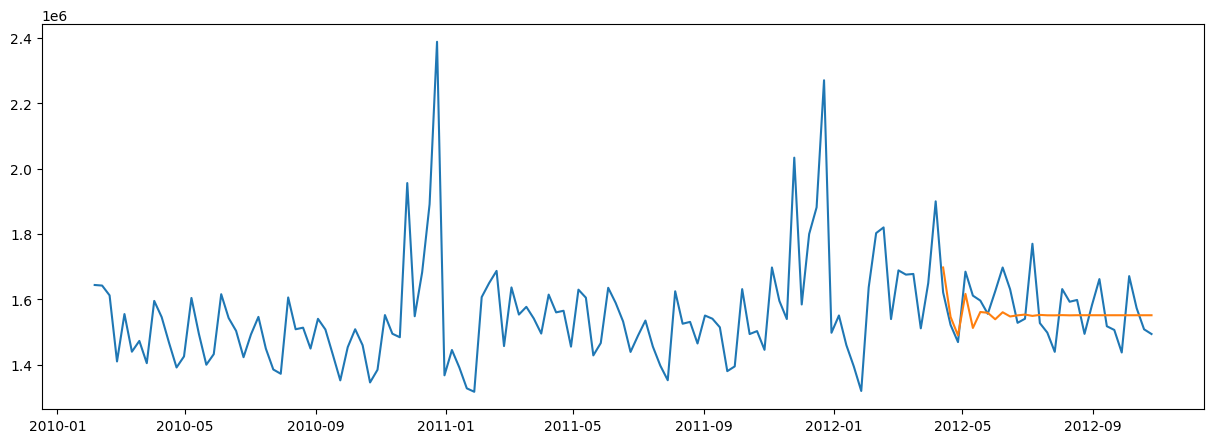

In [51]:
plt.figure(figsize=(15,5))
plt.plot(final_data)
plt.show()

In [52]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
model = SARIMAX(train_data, order = (2, 0, 2), seasonal_order = (2, 0, 2, 52))

In [53]:
model = model.fit()

In [54]:
final_data['SARIMAX_Predicted'] = model.predict(start=train_len, end=length-1, dynamic = True)

In [55]:
final_data

,Weekly_Sales,ARIMA_Predicted,SARIMAX_Predicted
2010-02-05,1643690.90,NaN,NaN
2010-02-12,1641957.44,NaN,NaN
2010-02-19,1611968.17,NaN,NaN
2010-02-26,1409727.59,NaN,NaN
2010-03-05,1554806.68,NaN,NaN
...,...,...,...
2012-09-28,1437059.26,1.551100e+06,1.562325e+06
2012-10-05,1670785.97,1.551078e+06,1.694291e+06
2012-10-12,1573072.81,1.551097e+06,1.619111e+06
2012-10-19,1508068.77,1.551087e+06,1.614591e+06


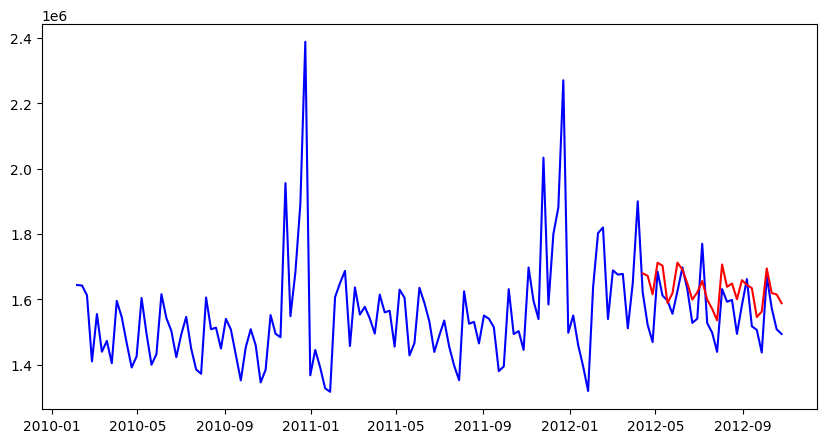

In [56]:
plt.figure(figsize=(10,5))
plt.plot(final_data['Weekly_Sales'], color='blue')
plt.plot(final_data['SARIMAX_Predicted'], color='red')


In [57]:
forecasted_results = model.forecast(steps = 48)

In [58]:
pd.DataFrame(forecasted_results).head()

,predicted_mean
2012-04-13,1.679131e+06
2012-04-20,1.671982e+06
2012-04-27,1.615155e+06
2012-05-04,1.711789e+06
2012-05-11,1.702758e+06


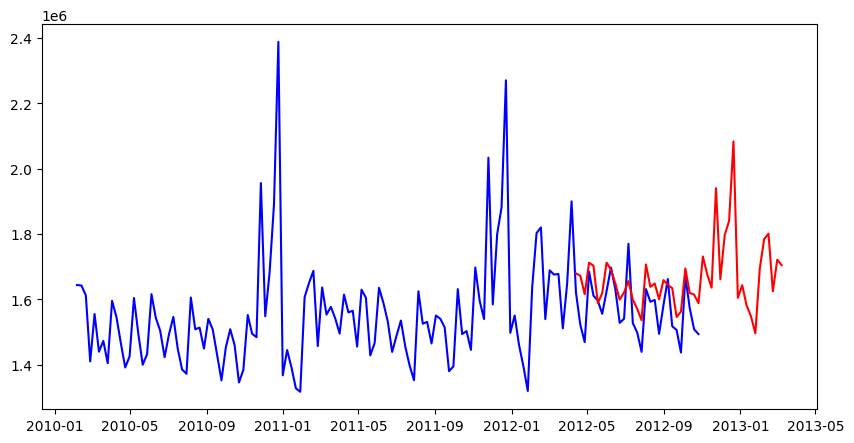

In [59]:
plt.figure(figsize=(10,5))
plt.plot(final_data['Weekly_Sales'], color='blue')
# plt.plot(final_data['SARIMAX_Predicted'], color='green')
plt.plot(forecasted_results, color='red')
plt.show()

In [60]:
# Evaluating Using RMSE

from sklearn.metrics import mean_squared_error
RMSE2_Sarimax = mean_squared_error(final_data['Weekly_Sales'].iloc[train_len:], final_data['SARIMAX_Predicted'].iloc[train_len:], squared = False)

In [61]:
print(f'RMSE for SARIMAX : {RMSE2_Sarimax}')

RMSE for SARIMAX : 81855.378149998


In [62]:
RMSE2_arima = mean_squared_error(final_data['Weekly_Sales'].iloc[train_len:], final_data['ARIMA_Predicted'].iloc[train_len:], squared = False)

In [63]:
print(f'RMSE for ARIMA : {RMSE2_arima}')

RMSE for ARIMA : 79575.04293387092


In [66]:
df.sample(2)

,Store,Weekly_Sales
2010-06-18,5,313795.60
2010-02-12,12,1117863.33


In [70]:
def predict_sales_for_store(i,df):
    X=df[df['Store']==i]
    X.drop(columns=['Store'],inplace=True)
    plt.figure(figsize=(15,5))
    plt.plot(X['Weekly_Sales'])
    plt.title(f"Sales of store {i} in the last 3 years")
    plt.show()
    decompose = seasonal_decompose(X['Weekly_Sales'], period = 52)
    decompose.plot()
    plt.title(f"Decomposition of Sales by trend, seasonality and residue")
    plt.show()
    result=adfuller(X['Weekly_Sales'].dropna())
    if(result[1])<0.05:
        print('Data IS stationary, p value -',result[1])
    else:
        print('Data is NOT stationary, p value -',result[1])
    
    from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
    plot_acf(X['Weekly_Sales'].dropna())
    plt.title(f"ACF Graph for Sales in Store {i}")
    plt.show()
    plot_pacf(X['Weekly_Sales'].dropna())
    plt.title(f"PACF Graph for Sales in Store {i}")
    plt.show()
    final_data=X['Weekly_Sales'].dropna()
    length=len(final_data)
    train_len=int(length*0.8)
    print(f'complete length- {length}  train length- {train_len} ')
    final_data=pd.DataFrame(final_data)
    train_data = final_data.iloc[:train_len]['Weekly_Sales']
    test_data = final_data .iloc[train_len+1:]['Weekly_Sales']
    arima_model = ARIMA(train_data, order = (2, 0, 2))
    trained_model = arima_model.fit()
    final_data['ARIMA_Predicted'] = trained_model.predict(start=train_len, end=length-1, dynamic = True)
    plt.figure(figsize=(15,5))
    plt.plot(final_data)
    plt.title(f"ARIMA prediction for Sales in Store {i}")
    plt.show()
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    model = SARIMAX(train_data, order = (2, 0, 2), seasonal_order = (2, 0, 2, 52))
    model = model.fit()
    final_data['SARIMAX_Predicted'] = model.predict(start=train_len, end=length-1, dynamic = True)
    plt.figure(figsize=(10,5))
    plt.plot(final_data['Weekly_Sales'], color='blue')
    plt.plot(final_data['SARIMAX_Predicted'], color='red')
    plt.title(f"SARIMAX Predictions for Sales in Store {i}")
    plt.show()
    forecasted_results = model.forecast(steps = 48)
    plt.figure(figsize=(10,5))
    plt.plot(final_data['Weekly_Sales'], color='blue')
    plt.plot(forecasted_results, color='red')
    plt.title(f"Forecast of Sales in Store {i}")
    plt.show()
    from sklearn.metrics import mean_squared_error
    RMSE2_Sarimax = mean_squared_error(final_data['Weekly_Sales'].iloc[train_len:], final_data['SARIMAX_Predicted'].iloc[train_len:], squared = False)
    print(f'RMSE for SARIMAX : {RMSE2_Sarimax}')
    RMSE2_arima = mean_squared_error(final_data['Weekly_Sales'].iloc[train_len:], final_data['ARIMA_Predicted'].iloc[train_len:], squared = False)
    print(f'RMSE for ARIMA : {RMSE2_arima}')


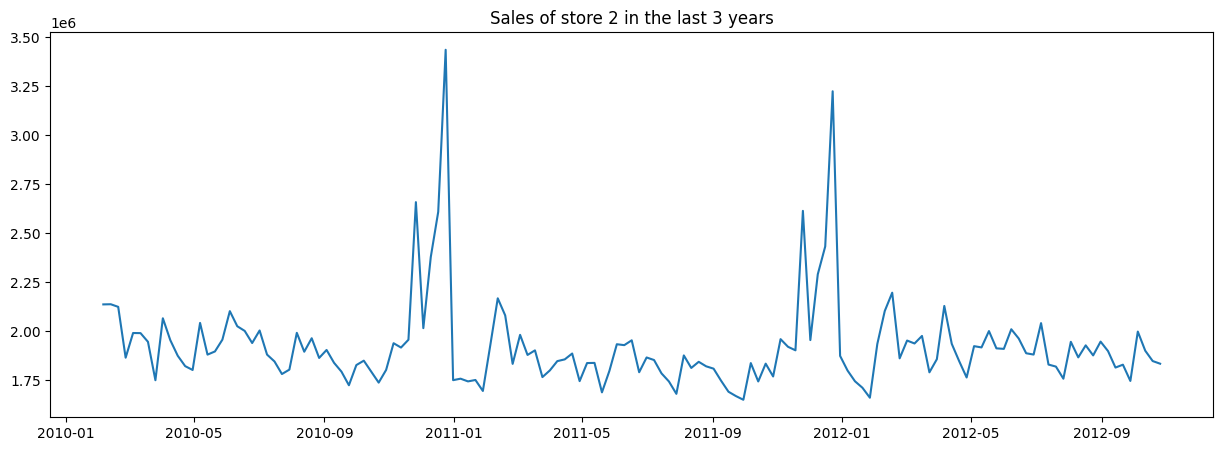

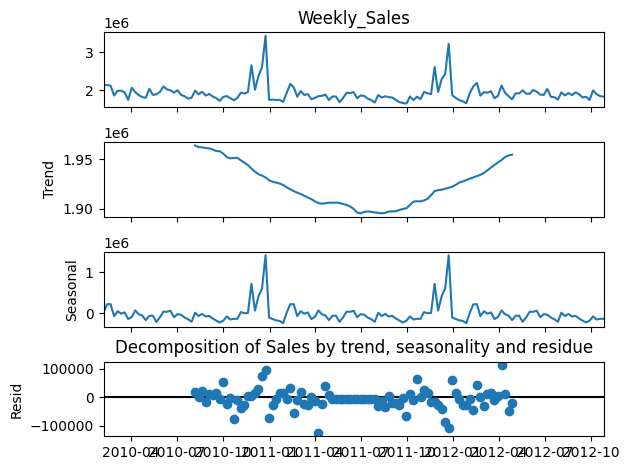

Data IS stationary, p value - 0.003990207089066331


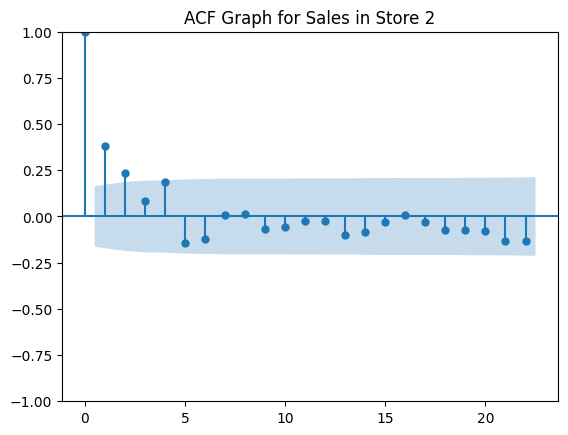

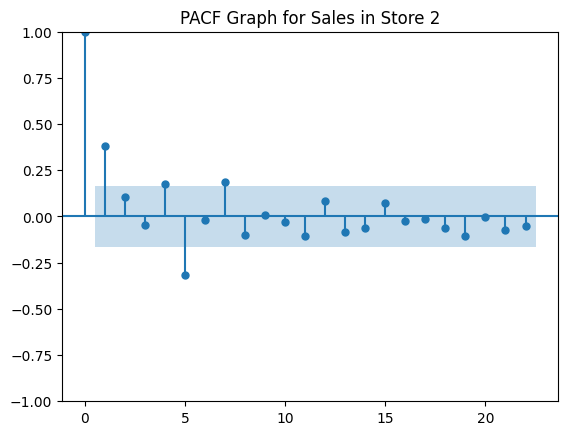

complete length- 143  train length- 114 


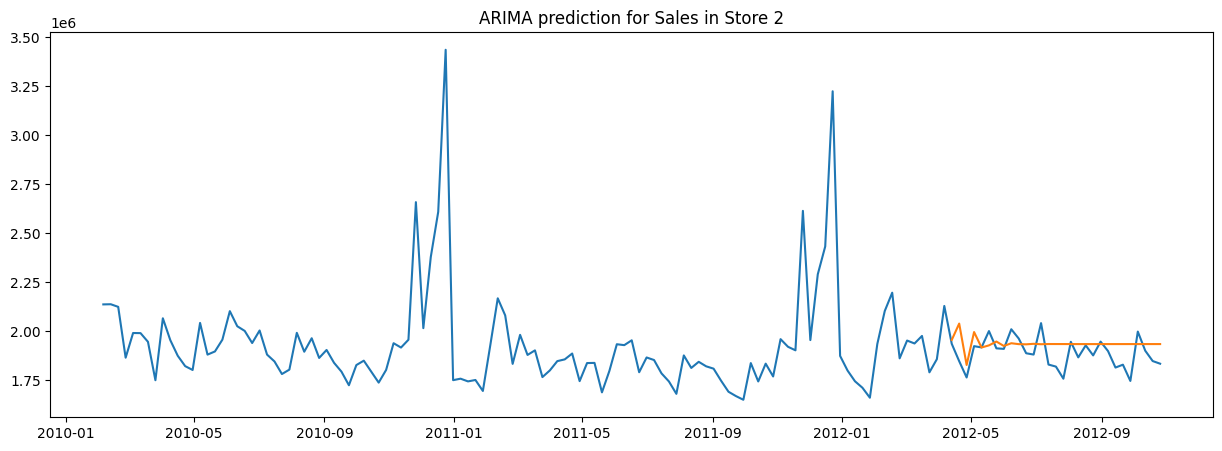

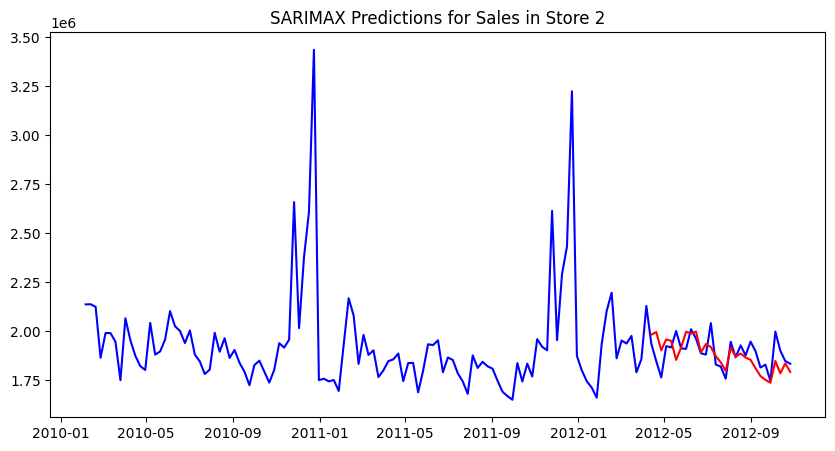

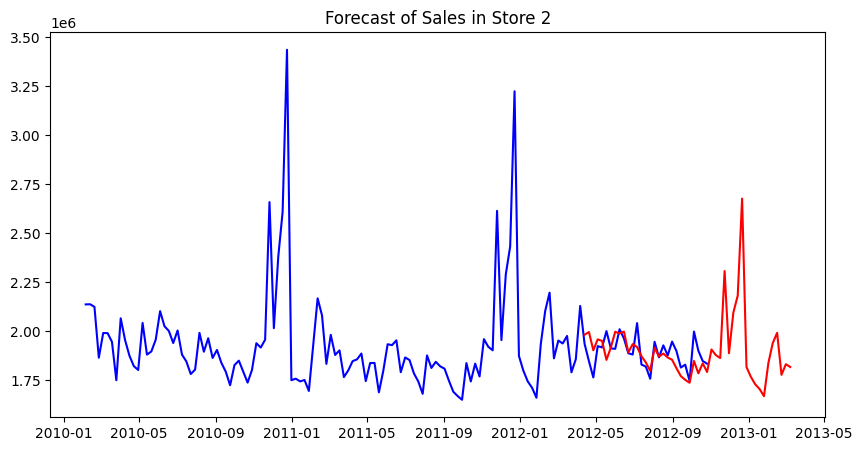

RMSE for SARIMAX : 75021.13643365949
RMSE for ARIMA : 87928.31837893058


In [71]:
# Predicting Sales for Store No 2

predict_sales_for_store(2,df)

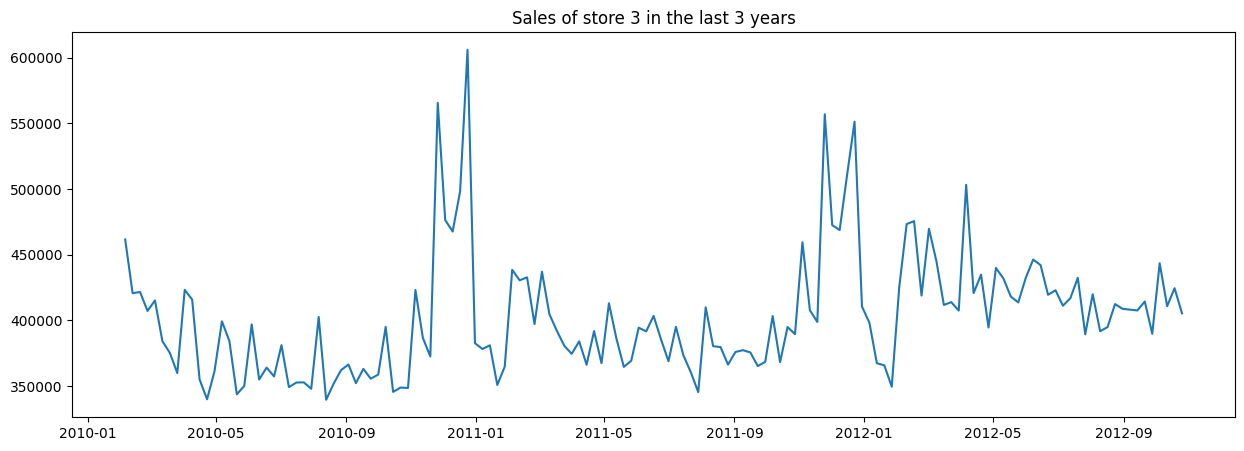

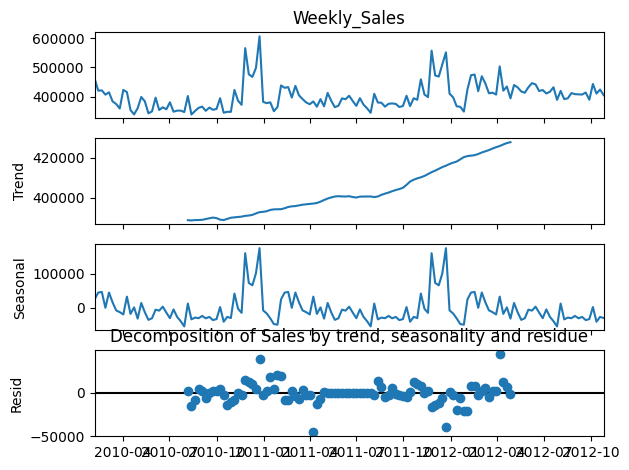

Data IS stationary, p value - 0.038409261798312666


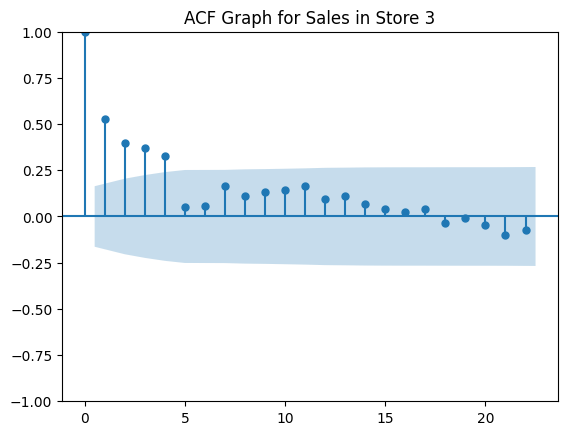

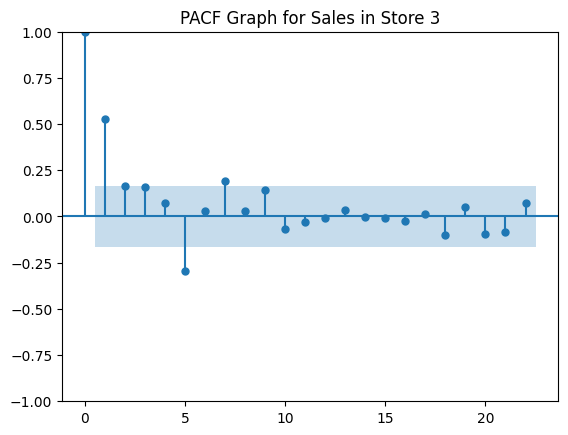

complete length- 143  train length- 114 


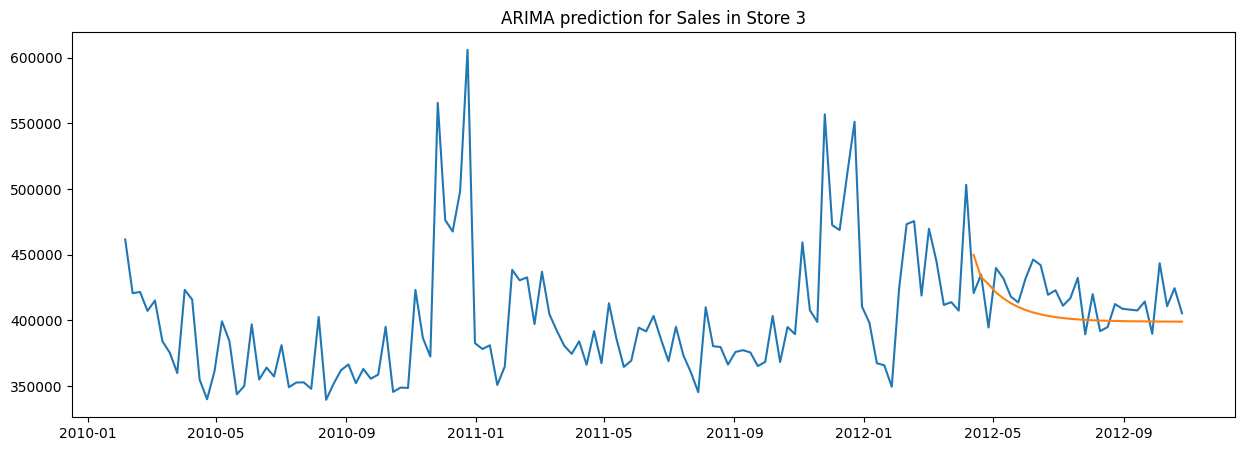

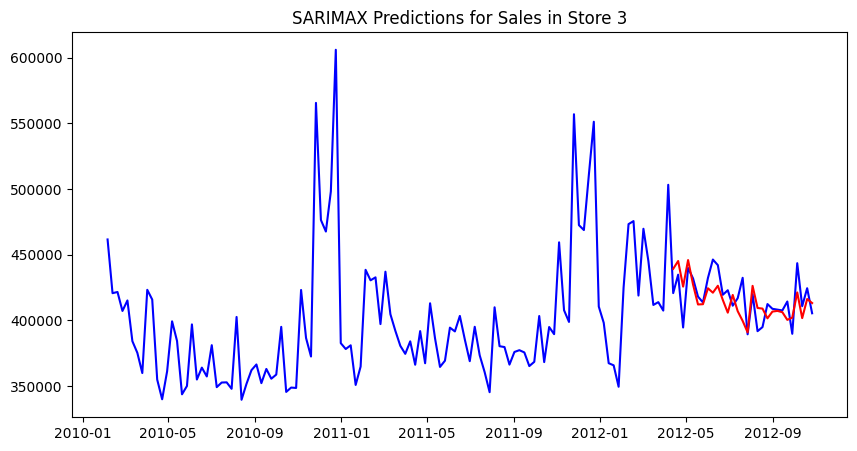

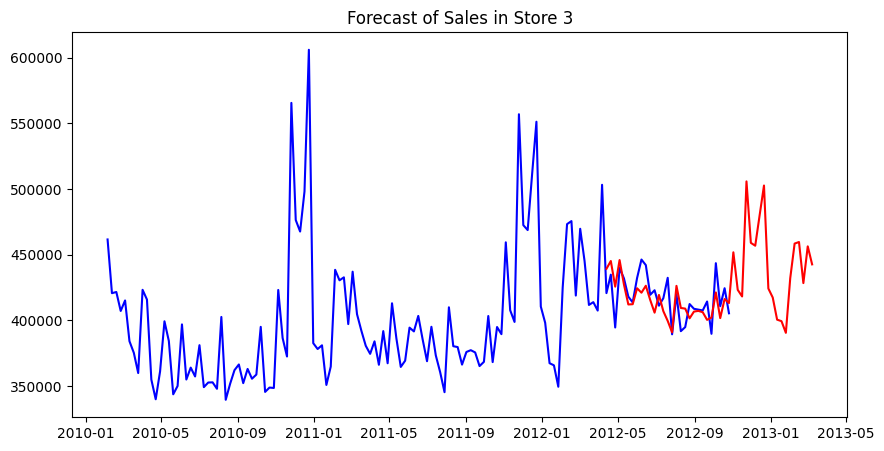

RMSE for SARIMAX : 14058.55068991664
RMSE for ARIMA : 20606.623961055877


In [72]:
# Predicting Sales for Store No 3

predict_sales_for_store(3,df)

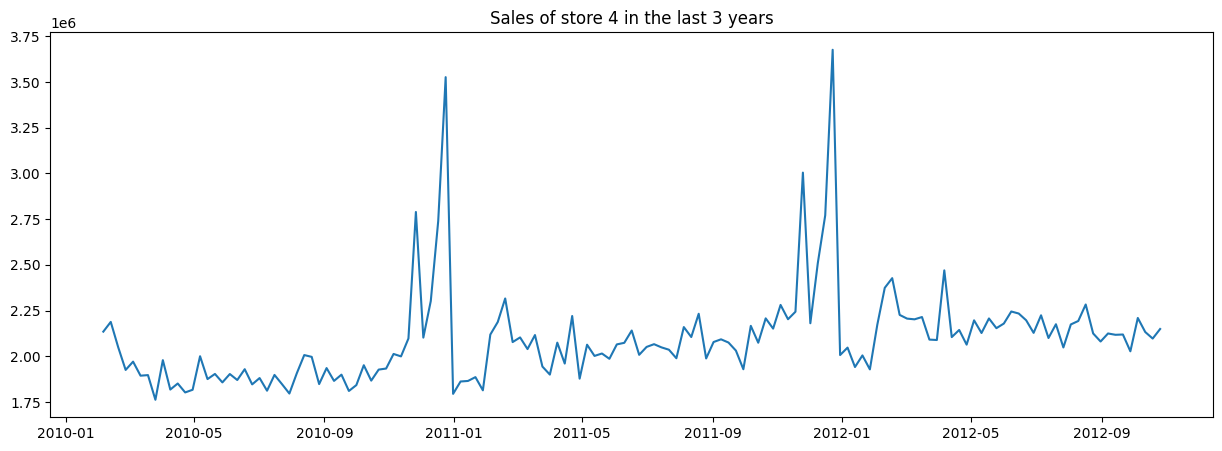

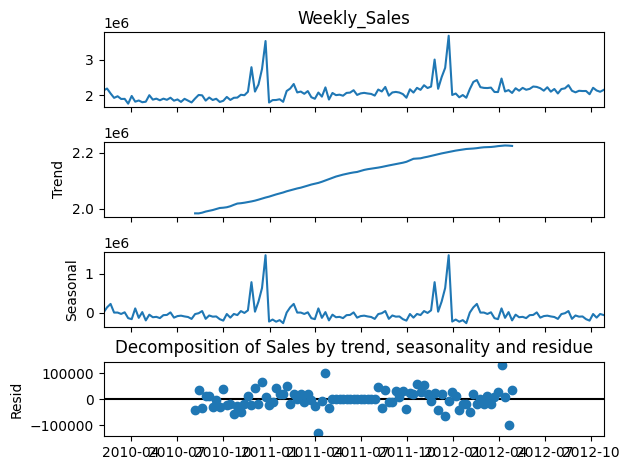

Data IS stationary, p value - 0.04779866223669849


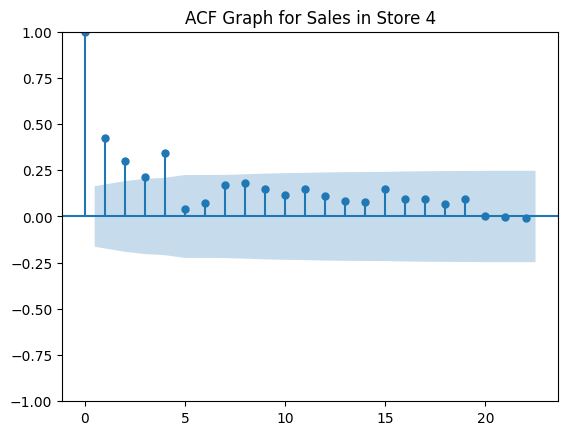

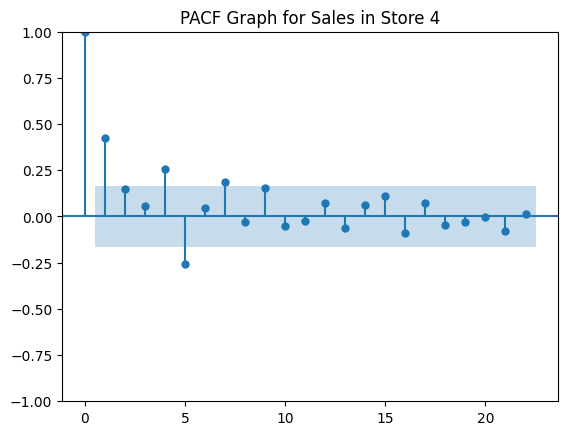

complete length- 143  train length- 114 


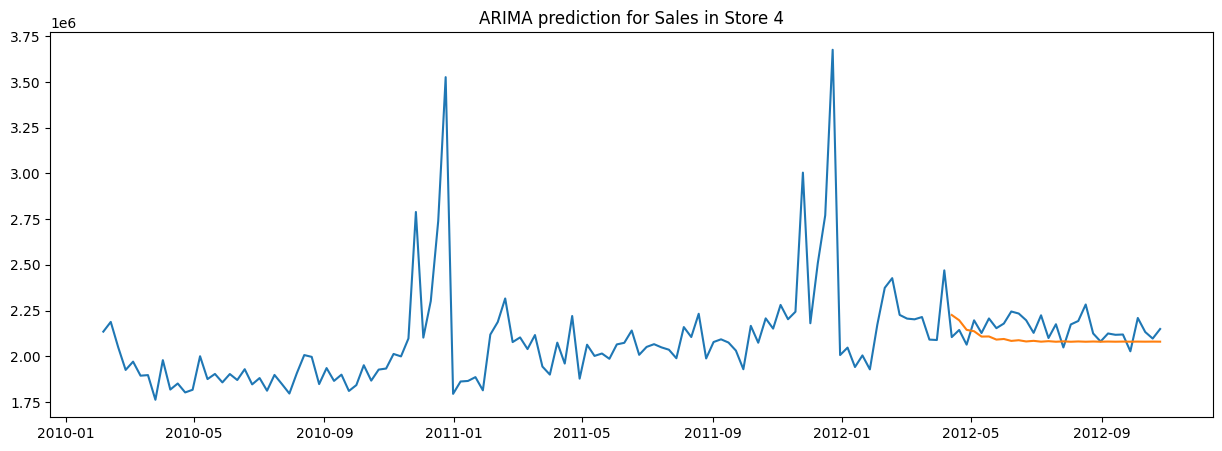

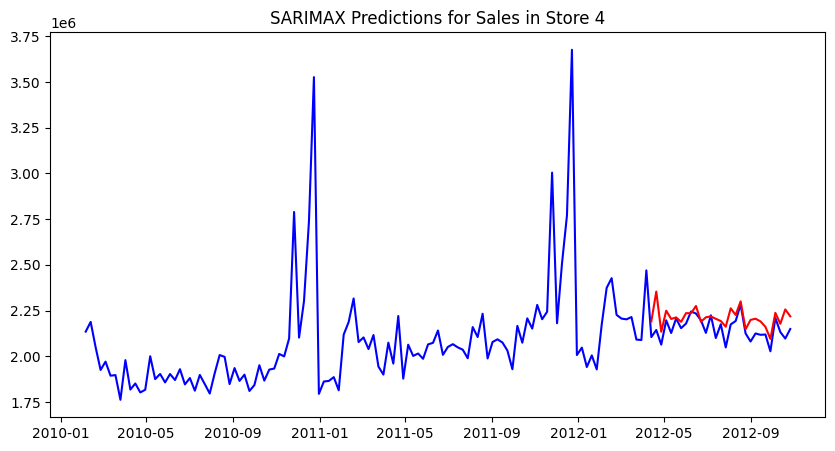

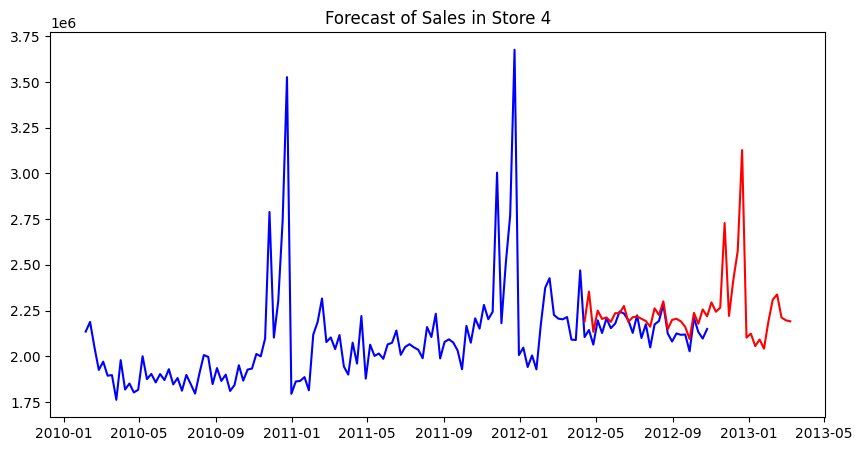

RMSE for SARIMAX : 78299.35760771096
RMSE for ARIMA : 90874.02272344216


In [73]:
# Predicting Sales for Store No 4

predict_sales_for_store(4,df)

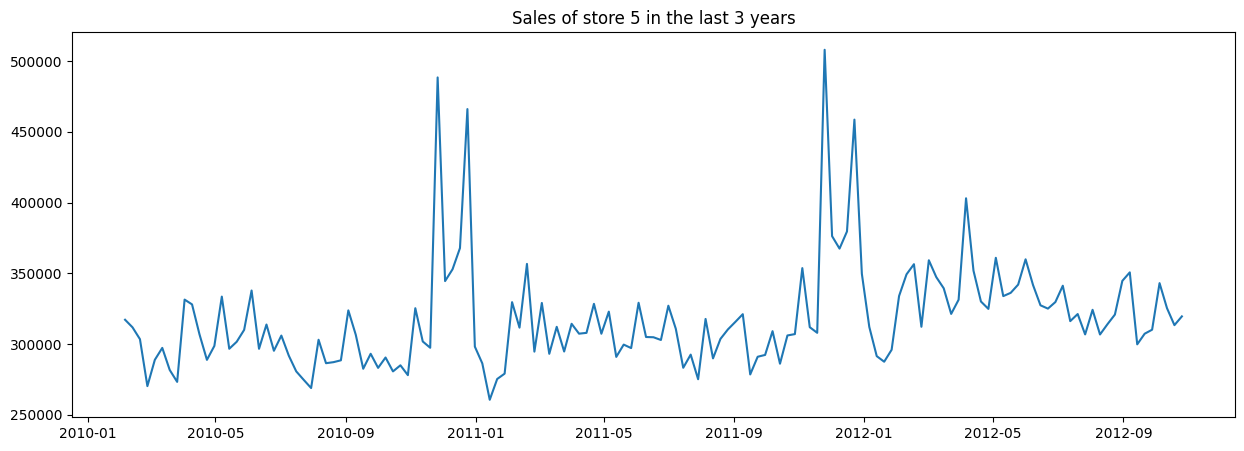

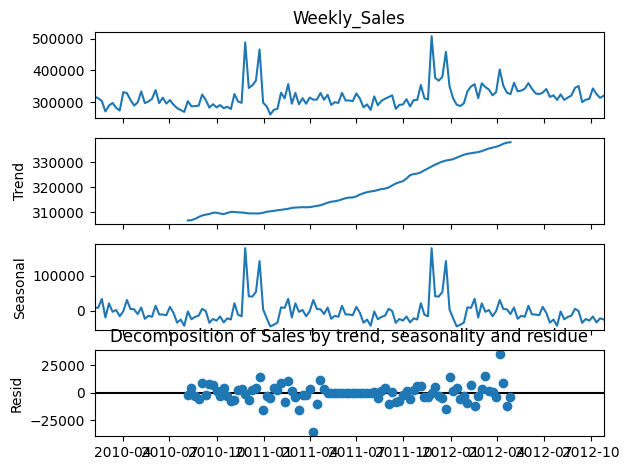

Data IS stationary, p value - 0.00042517056141923467


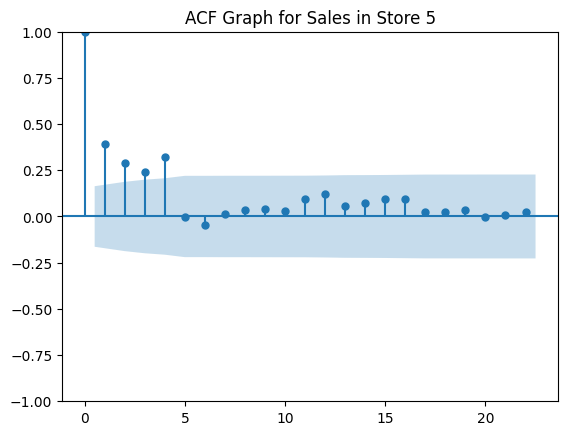

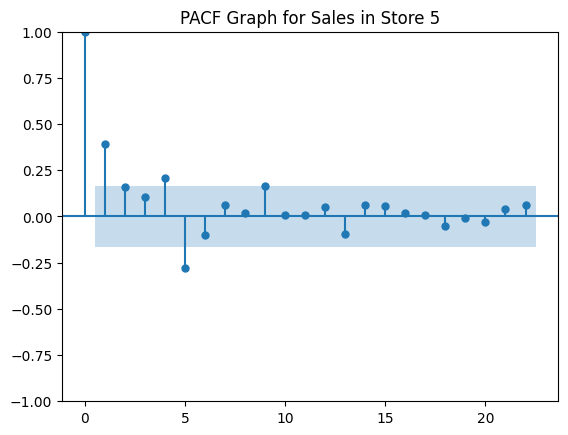

complete length- 143  train length- 114 


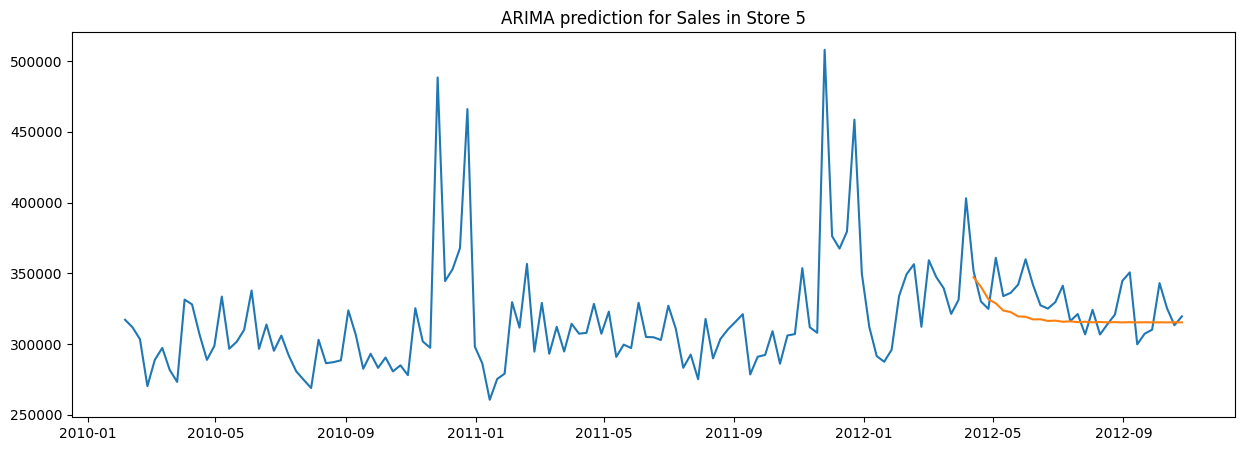

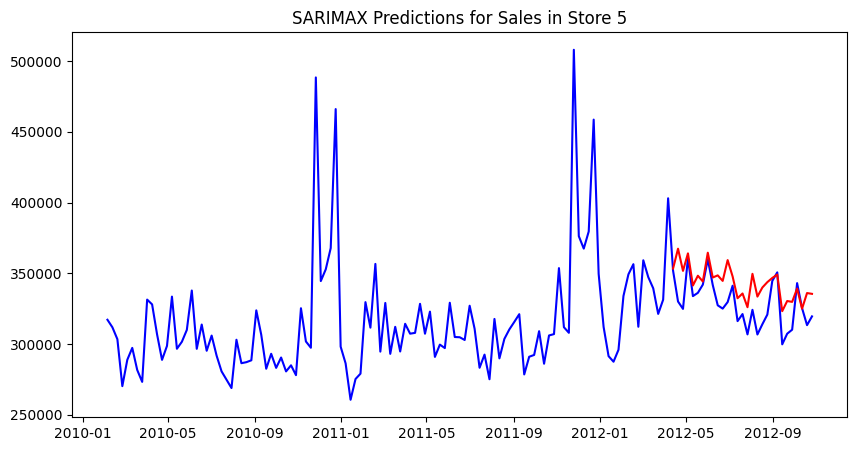

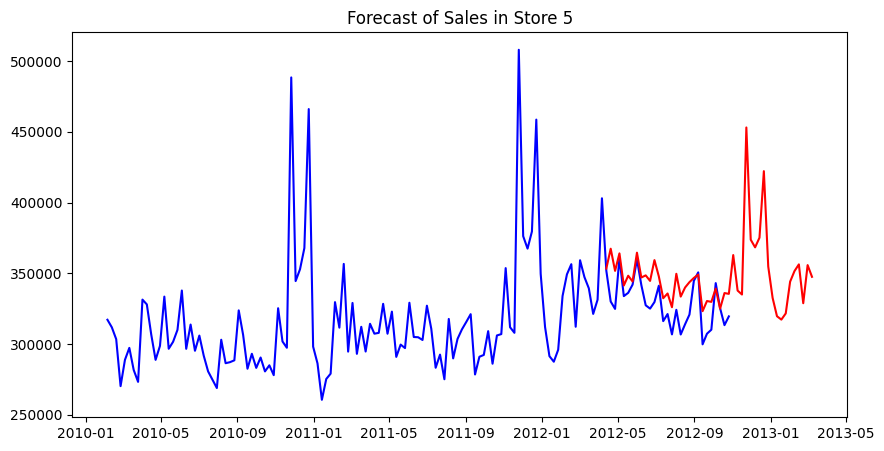

RMSE for SARIMAX : 18381.170054500464
RMSE for ARIMA : 17473.564145264274


In [74]:
# Predicting Sales for Store No 5

predict_sales_for_store(5,df)